# Feature Engineering

In [1]:
# Data libraries
import pandas as pd
import numpy as np

# Plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity, cosine_distances

In [2]:
# Load data
email = pd.read_pickle("email.pkl")
ldap = pd.read_pickle("ldap.pkl")
insider = pd.read_pickle("insider.pkl")

## Metadata
### Behavioural Features

In [3]:
# create a weekly identifier based on the email date
email["week_start"] = email["date"].dt.to_period("W").dt.start_time

# the number of recipients for each email
email["num_receivers"] = email["to"].str.split(";").str.len()

# identify whether each email contains an attachment
email["has_attachment"] = email["attachments"].notna()

In [4]:
# aggregate email metadata into weekly behavioural features for each user
bf = (
    email
    .groupby(["user", "week_start"])
    .agg(
        email_count=("user", "size"),
        avg_size=("size", "mean"),
        total_size=("size", "sum"),
        max_size=("size", "max"),
        avg_receivers=("num_receivers", "mean"),
        max_receivers=("num_receivers", "max"),
        attachment_ratio=("has_attachment", "mean")
    )
    .reset_index()
)

bf

,user,week_start,email_count,avg_size,total_size,max_size,avg_receivers,max_receivers,attachment_ratio
0,AAB0162,2010-01-04,45,242448.955556,10910203,2809107,1.977778,4,0.111111
1,AAB0162,2010-01-11,45,379515.311111,17078189,3612125,2.022222,5,0.244444
2,AAB0162,2010-01-18,45,445996.666667,20069850,5114363,1.800000,4,0.177778
3,AAB0162,2010-01-25,36,300391.666667,10814100,4263681,1.944444,4,0.111111
4,AAB0162,2010-02-01,45,188223.177778,8470043,2110677,1.822222,3,0.111111
...,...,...,...,...,...,...,...,...,...
283486,ZZO2997,2011-05-02,70,365357.557143,25575029,3971599,1.885714,4,0.185714
283487,ZZO2997,2011-05-09,63,205843.841270,12968162,6691465,1.968254,5,0.142857
283488,ZZO2997,2011-05-16,69,161089.318841,11115163,2232396,1.855072,4,0.101449
283489,ZZO2997,2011-05-23,70,590114.685714,41308028,8295122,2.171429,5,0.228571


In [5]:
# weekly unique receivers
email["to_list"] = email["to"].str.split(";")

# count the number of unique recipients contacted by each user per week
receiver_weekly = (
    email[["user", "week_start", "to_list"]]
    .explode("to_list")
    .groupby(["user", "week_start"])["to_list"]
    .nunique()
    .reset_index(name="unique_receivers")
)

bf = bf.merge(
    receiver_weekly,
    on=["user", "week_start"],
    how="left"
)


# external receiver count
receiver_df = (
    email[["user", "week_start", "to_list"]]
    .explode("to_list")
)

receiver_df["is_external"] = (
    ~receiver_df["to_list"]
    .str.contains("@dtaa.com", case=False, na=False)
)

# count the number of unique external recipients contacted by each user per week
external_receiver_count = (
    receiver_df[receiver_df["is_external"]]
    .groupby(["user", "week_start"])["to_list"]
    .nunique()
    .reset_index(name="external_receiver_count")
)

bf = bf.merge(
    external_receiver_count,
    on=["user", "week_start"],
    how="left"
)

# fill missing values with 0
bf["external_receiver_count"] = (
    bf["external_receiver_count"].fillna(0)
)


# external receiver ratio
receiver_df["is_external"] = (
    ~receiver_df["to_list"]
    .str.contains("@dtaa.com", case=False, na=False)
)

# calculate the proportion of external recipients for each user per week
external_receiver_ratio = (
    receiver_df
    .groupby(["user", "week_start"])["is_external"]
    .mean()
    .reset_index(name="external_receiver_ratio")
)

bf = bf.merge(
    external_receiver_ratio,
    on=["user", "week_start"],
    how="left"
)


# night-time email ratio
email["night_time"] = (
    (email["date"].dt.hour < 7) |
    (email["date"].dt.hour >= 18)
).astype(int)

# calculate the proportion of emails sent during night-time hours
night_time_email_ratio = (
    email[["user", "week_start", "night_time"]]
    .groupby(["user", "week_start"])["night_time"]
    .mean()
    .reset_index(name="night_time_email_ratio")
)

bf = bf.merge(
    night_time_email_ratio,
    on=["user", "week_start"],
    how="left"
)


# weekend email ratio
email["weekend"] = (
    email["date"].dt.dayofweek >= 5
).astype(int)

# calculate the proportion of emails sent during weekends
weekend_email_ratio = (
    email[["user", "week_start", "weekend"]]
    .groupby(["user", "week_start"])["weekend"]
    .mean()
    .reset_index(name="weekend_email_ratio")
)

bf = bf.merge(
    weekend_email_ratio,
    on=["user", "week_start"],
    how="left"
)


# weekly maximum daily email count
daily_email = (
    email.groupby(["user", "date"])
    .size()
    .reset_index(name="daily_email_count")
)

daily_email["week_start"] = (
    pd.to_datetime(daily_email["date"])
    .dt.to_period("W")
    .dt.start_time
)

# find the maximum number of emails sent by a user on a single day within each week
max_daily_email = (
    daily_email
    .groupby(["user", "week_start"])["daily_email_count"]
    .max()
    .reset_index(name="max_daily_email")
)

bf = bf.merge(
    max_daily_email,
    on=["user", "week_start"],
    how="left"
)


# average time between emails
email["time_diff"] = (
    email.groupby("user")["date"]
    .diff()
    .dt.total_seconds() / 3600
)

# calculate the average time interval between emails for each user per week
avg_interval_weekly = (
    email.groupby(["user", "week_start"])["time_diff"]
    .mean()
    .reset_index(name="avg_time_between_emails")
)

bf = bf.merge(
    avg_interval_weekly,
    on=["user", "week_start"],
    how="left"
)

# fill missing intervals using the median value
bf["avg_time_between_emails"] = (
    bf["avg_time_between_emails"]
    .fillna(bf["avg_time_between_emails"].median())
)


# minimum time between emails
min_interval_weekly = (
    email.groupby(["user", "week_start"])["time_diff"]
    .min()
    .reset_index(name="min_time_between_emails")
)

bf = bf.merge(
    min_interval_weekly,
    on=["user", "week_start"],
    how="left"
)

# fill missing intervals using the median value
bf["min_time_between_emails"] = (
    bf["min_time_between_emails"]
    .fillna(bf["min_time_between_emails"].median())
)

In [6]:
# deviation features
deviation_features = [
    "email_count",
    "total_size",
    "external_receiver_ratio",
    "night_time_email_ratio",
    "weekend_email_ratio",
    "max_daily_email"
]

# define the number of previous weeks used to calculate the historical baseline
window = 8

# calculate the historical baseline for each user using previous weekly activity
for feature in deviation_features:
    bf[f"{feature}_baseline"] = (
        bf
        .groupby("user")[feature]
        .transform(
            lambda x: x.shift(1).rolling(
                window=window,
                min_periods=3
            ).mean()
        )
    )

# calculate the deviation of each week's activity from the user's historical baseline
for feature in deviation_features:
    bf[f"{feature}_deviation"] = (
        bf[feature] - bf[f"{feature}_baseline"]
    )

# remove the intermediate baseline columns
baseline_columns = [
    f"{feature}_baseline"
    for feature in deviation_features
]

bf = bf.drop(columns=baseline_columns)

# identify the final deviation features
deviation_columns = [
    f"{feature}_deviation"
    for feature in deviation_features
]

# fill missing deviation values with 0
bf[deviation_columns] = (
    bf[deviation_columns].fillna(0)
)

bf.shape

(283491, 23)

In [7]:
bf.head()

,user,week_start,email_count,avg_size,total_size,max_size,avg_receivers,max_receivers,attachment_ratio,unique_receivers,...,weekend_email_ratio,max_daily_email,avg_time_between_emails,min_time_between_emails,email_count_deviation,total_size_deviation,external_receiver_ratio_deviation,night_time_email_ratio_deviation,weekend_email_ratio_deviation,max_daily_email_deviation
0,AAB0162,2010-01-04,45,242448.955556,10910203,2809107,1.977778,4,0.111111,37,...,0.0,1,2.213220,0.000556,0.00,0.0,0.000000,0.000000,0.0,0.0
1,AAB0162,2010-01-11,45,379515.311111,17078189,3612125,2.022222,5,0.244444,37,...,0.0,1,3.924648,0.000556,0.00,0.0,0.000000,0.000000,0.0,0.0
2,AAB0162,2010-01-18,45,445996.666667,20069850,5114363,1.800000,4,0.177778,41,...,0.0,1,3.650586,0.000278,0.00,0.0,0.000000,0.000000,0.0,0.0
3,AAB0162,2010-01-25,36,300391.666667,10814100,4263681,1.944444,4,0.111111,33,...,0.0,1,4.634360,0.000278,-9.00,-5205314.0,-0.035157,-0.024074,0.0,0.0
4,AAB0162,2010-02-01,45,188223.177778,8470043,2110677,1.822222,3,0.111111,41,...,0.0,1,3.794833,0.002222,2.25,-6248042.5,-0.019051,0.020833,0.0,0.0


#### Organisational features

In [8]:
# convert LDAP dates to a consistent year-month format
ldap["date"] = pd.to_datetime(
    ldap["date"],
    format="%Y-%m"
).dt.to_period("M").astype(str)

In [9]:
# select the organisational features to be incorporated from LDAP
ldap_features = [
    "user_id",
    "date",
    "role",
    "business_unit",
    "functional_unit",
    "department",
    "team"
]

bf_df = bf.copy()

# convert weekly dates to month identifiers for matching
bf_df["month"] = (
    bf_df["week_start"]
    .dt.to_period("M")
    .astype(str)
)

bf_of = bf_df.merge(
    ldap[ldap_features],
    left_on=["user", "month"],
    right_on=["user_id", "date"],
    how="left"
)

In [10]:
# define categorical features for one-hot encoding
cat_cols = [
    "role",
    "business_unit",
    "functional_unit",
    "department",
    "team"
]

# convert categorical features into one-hot encoded variables
bf_of = pd.get_dummies(
    bf_of,
    columns=cat_cols,
    dummy_na=True
)

In [11]:
# define the columns needed to be removed
drop_cols = [
    "user_id",
    "date",
    "month",
    "employee_name",
    "email"
]

# remove columns
bf_of = bf_of.drop(
    columns=[
        c for c in drop_cols
        if c in bf_of.columns
    ]
)

bf_of.shape

(283491, 196)

In [12]:
bf_of.isna().sum()

user                             0
week_start                       0
email_count                      0
avg_size                         0
total_size                       0
                                ..
team_9 - BuildingSecurity        0
team_9 - MaterialsEngineering    0
team_9 - Stockroom               0
team_9 - WebSoftware             0
team_nan                         0
Length: 196, dtype: int64

#### Combine with answer dataset

In [13]:
metadata = bf_of.copy()

# initialise all user-week records as benign
metadata["malicious"] = 0

# label records that overlap with a known malicious activity period
for _, row in insider.iterrows():
    metadata.loc[
        (metadata["user"] == row["user"]) &
        (metadata["week_start"] <= row["end"]) &
        (metadata["week_start"] + pd.Timedelta(days=6) >= row["start"]),
        "malicious"
    ] = 1

metadata.shape

(283491, 197)

In [14]:
metadata.head()

,user,week_start,email_count,avg_size,total_size,max_size,avg_receivers,max_receivers,attachment_ratio,unique_receivers,...,team_8 - AssemblyDept,team_8 - DesktopSoftware,team_8 - ElectricalEngineering,team_8 - ElectronicSecurity,team_9 - BuildingSecurity,team_9 - MaterialsEngineering,team_9 - Stockroom,team_9 - WebSoftware,team_nan,malicious
0,AAB0162,2010-01-04,45,242448.955556,10910203,2809107,1.977778,4,0.111111,37,...,False,False,False,False,False,False,False,False,False,0
1,AAB0162,2010-01-11,45,379515.311111,17078189,3612125,2.022222,5,0.244444,37,...,False,False,False,False,False,False,False,False,False,0
2,AAB0162,2010-01-18,45,445996.666667,20069850,5114363,1.800000,4,0.177778,41,...,False,False,False,False,False,False,False,False,False,0
3,AAB0162,2010-01-25,36,300391.666667,10814100,4263681,1.944444,4,0.111111,33,...,False,False,False,False,False,False,False,False,False,0
4,AAB0162,2010-02-01,45,188223.177778,8470043,2110677,1.822222,3,0.111111,41,...,False,False,False,False,False,False,False,False,False,0


#### Behavioural feature analysis

In [15]:
# compare mean behavioural deviations between benign and malicious user-weeks
metadata.groupby("malicious")[
    [
        "email_count_deviation",
        "total_size_deviation",
        "external_receiver_ratio_deviation",
        "night_time_email_ratio_deviation",
        "weekend_email_ratio_deviation",
        "max_daily_email_deviation"
    ]
].mean()

,email_count_deviation,total_size_deviation,external_receiver_ratio_deviation,night_time_email_ratio_deviation,weekend_email_ratio_deviation,max_daily_email_deviation
malicious,,,,,,
0,-0.406248,-1.922103e+05,0.003191,-0.000189,-0.001177,-0.001419
1,2.645833,7.106198e+06,0.011092,-0.000254,0.000000,0.076389


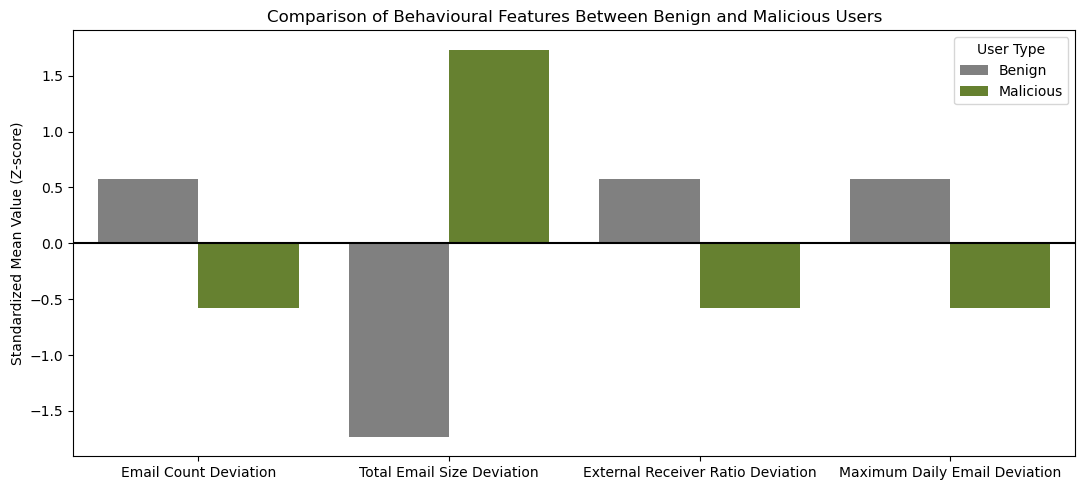

In [16]:
# Class-level mean comparison of behavioural features
# Compare the average feature values between benign and malicious users
features = [
    "email_count_deviation",
    "total_size_deviation",
    "external_receiver_ratio_deviation",
    "max_daily_email_deviation"
]

# Rename feature names for better visual presentation in the plot
feature_labels = {
    "email_count_deviation": "Email Count Deviation",
    "total_size_deviation": "Total Email Size Deviation",
    "external_receiver_ratio_deviation": "External Receiver Ratio Deviation",
    "max_daily_email_deviation": "Maximum Daily Email Deviation"
}


# Calculate class-level mean values
plot_df = (
    metadata
    .groupby("malicious")[features]
    .mean()
    .T
)

# Standardize feature values to compare relative differences
ss = StandardScaler()

plot_df_scaled = pd.DataFrame(
    ss.fit_transform(plot_df),
    index=plot_df.index,
    columns=plot_df.columns
)

# Replace technical feature names
plot_df_scaled = plot_df_scaled.rename(index=feature_labels)

# Convert dataframe for plotting
plot_df_scaled = (
    plot_df_scaled
    .reset_index()
    .melt(
        id_vars="index",
        var_name="malicious",
        value_name="value"
    )
)

# Replace labels
plot_df_scaled["malicious"] = plot_df_scaled["malicious"].map({
    0: "Benign",
    1: "Malicious"
})

# Define colours for each class
palette = {
    "Benign": "grey",
    "Malicious": "olivedrab"
}

plt.figure(figsize=(11,5))

sns.barplot(
    data=plot_df_scaled,
    x="index",
    y="value",
    hue="malicious",
    palette=palette
)

plt.ylabel("Standardized Mean Value (Z-score)")
plt.xlabel("")
plt.title("Comparison of Behavioural Features Between Benign and Malicious Users")
plt.axhline(0,color="black")
plt.legend(title="User Type")
plt.tight_layout()
plt.show()

## Semantic Data

In [17]:
# combine email content into a single text document for each user-week
#content_weekly = (
#    email.groupby(["user", "week_start"])["content"]
#    .apply(" ".join)
#    .reset_index()
#)

content_weekly = pd.read_pickle("content_weekly.pkl")

### TF-IDF with truncated SVD

In [18]:
## convert weekly email content into a TF-IDF representation
# vectorizer = TfidfVectorizer(stop_words="english")
# tfidf_matrix = vectorizer.fit_transform(content_weekly["content"])

# print(f"TF-IDF matrix shape: {tfidf_matrix.shape}  "
#       f"({tfidf_matrix.shape[0]}  user-weeks x {tfidf_matrix.shape[1]} vocabulary terms)")
## TF-IDF matrix shape: (283,491 , 72,507) 283,491 user-weeks x 72,507 vocabulary terms

In [19]:
## reduce the high-dimensional TF-IDF representation using truncated SVD
# svd = TruncatedSVD(n_components=100,random_state=42)
# tfidf_reduced = svd.fit_transform(tfidf_matrix)  

# tfidf_reduced.shape
##  (283,491 , 100)

In [20]:
## convert the reduced TF-IDF representation into a DataFrame
# tfidf = pd.DataFrame(
#    tfidf_reduced,
#    columns=[f"svd_{i}" for i in range(100)]
#)

tfidf = pd.read_pickle("tfidf.pkl")
# add user and weekly identifiers for merging with metadata features
tfidf["user"] = content_weekly["user"].values
tfidf["week_start"] = content_weekly["week_start"].values

tfidf.head()

,svd_0,svd_1,svd_2,svd_3,svd_4,svd_5,svd_6,svd_7,svd_8,svd_9,...,svd_92,svd_93,svd_94,svd_95,svd_96,svd_97,svd_98,svd_99,user,week_start
0,0.330581,-0.021076,-0.046218,-0.090601,-0.007347,0.031382,0.026602,-0.014586,0.039643,-0.086786,...,0.082872,-0.038820,0.078211,0.008785,0.047652,-0.061645,0.038174,-0.017885,AAB0162,2010-01-04
1,0.325301,-0.008983,-0.068126,-0.109545,-0.011806,-0.005117,0.005196,-0.039396,0.083155,-0.108102,...,0.074376,-0.049508,0.047082,0.017314,0.025457,-0.081430,0.042495,-0.041305,AAB0162,2010-01-11
2,0.329840,-0.049069,-0.045996,-0.068635,-0.012486,0.010189,0.020010,-0.011971,0.120543,-0.084459,...,0.011451,-0.031551,0.026001,0.001726,-0.009349,-0.000575,0.007139,-0.024922,AAB0162,2010-01-18
3,0.326348,-0.035265,-0.004777,-0.068875,-0.019163,0.032745,0.015903,-0.024480,0.053908,-0.058287,...,0.014397,0.014697,-0.085834,0.014136,-0.007802,-0.074276,-0.021500,0.037326,AAB0162,2010-01-25
4,0.359948,0.011434,-0.043285,-0.094994,-0.039707,0.034959,0.033151,-0.030212,0.031100,-0.072246,...,0.002531,0.009482,-0.013168,-0.018688,0.012432,-0.022596,0.011830,0.008925,AAB0162,2010-02-01


In [21]:
##  calculate the proportion of variance explained by the 100 SVD components
#print(
#    f"Explained variance: "
#    f"{svd.explained_variance_ratio_.sum():.2%}"
#)
## 24.04%

In [22]:
metadata_tfidf = metadata.merge(
    tfidf,
    on=["user", "week_start"],
    how="left"
)

metadata_tfidf.shape

(283491, 297)

### LLM embedding

In [23]:
# Load the pre-trained Sentence Transformer model
# model = SentenceTransformer('all-MiniLM-L6-v2')

In [24]:
# generate dense semantic embeddings for each user-week email content
# embeddings = model.encode(content_weekly["content"].fillna("").tolist())
embeddings = np.load("embeddings.npy")
embeddings.shape

(283491, 384)

In [25]:
# convert embeddings into a DataFrame
embedding_df = pd.DataFrame(embeddings,columns=[f"emb_{i}" for i in range(embeddings.shape[1])])

# add user and weekly identifiers for merging and following analysis
embedding_df["user"] = content_weekly["user"].values
embedding_df["week_start"] = content_weekly["week_start"].values

# sort embeddingsfor each user
embedding_df = embedding_df.sort_values(["user", "week_start"]).reset_index(drop=True)

embedding_df.shape

(283491, 386)

In [26]:
metadata_llm_embedding = metadata.merge(
    embedding_df,
    on=["user", "week_start"],
    how="left"
)

metadata_llm_embedding.shape

(283491, 581)

### Semantic deviation

In [27]:
# identify embedding feature columns
embedding_columns = [
    col for col in embedding_df.columns
    if col.startswith("emb_")
]

semantic_features = []

# process each user to establish personalised baselines
for user, group in embedding_df.groupby("user"):

    # sort to ensure only previous behaviour is used
    group = group.sort_values("week_start")

    vectors = group[embedding_columns].values

    # the first week has no historical baseline for comparison
    user_results = [
        {
            "user": user,
            "week_start": group.iloc[0]["week_start"],
            "semantic_deviation": np.nan,
            "mean_distance_to_history": np.nan,
            "max_distance_to_history": np.nan,
            "std_distance_to_history": np.nan
        }
    ]

    # compare each week's communication with the user's historical behaviour
    for i in range(1, len(vectors)):

        current_vector = vectors[i].reshape(1, -1)

        # calculate a historical baseline using the mean embedding of all previous weeks
        baseline = vectors[:i].mean(axis=0)

        similarity = cosine_similarity(
            current_vector,
            baseline.reshape(1, -1)
        )[0, 0]

        semantic_deviation = 1 - similarity

        # compare the current week with all previous weeks
        historical_vectors = vectors[:i]

        distances = cosine_distances(
            current_vector,
            historical_vectors
        )[0]

        #cCalculate distance-based semantic features
        mean_distance = distances.mean()
        max_distance = distances.max()
        std_distance = distances.std()

        user_results.append(
            {
                "user": user,
                "week_start": group.iloc[i]["week_start"],
                "semantic_deviation": semantic_deviation,
                "mean_distance_to_history": mean_distance,
                "max_distance_to_history": max_distance,
                "std_distance_to_history": std_distance
            }
        )

    semantic_features.extend(user_results)

semantic_deviation_df = pd.DataFrame(semantic_features)

# merge semantic deviation features with the metadata and embedding dataset
metadata_embedding_semantic = metadata_llm_embedding.merge(
    semantic_deviation_df,
    on=["user", "week_start"],
    how="left"
)

In [28]:
# check the missing values in the semantic deviation features
metadata_embedding_semantic[
    [
        "semantic_deviation",
        "mean_distance_to_history",
        "max_distance_to_history",
        "std_distance_to_history"
    ]
].isna().sum()

semantic_deviation          4000
mean_distance_to_history    4000
max_distance_to_history     4000
std_distance_to_history     4000
dtype: int64

In [29]:
# replace missing semantic deviation values with 0
metadata_embedding_semantic[
    [
        "semantic_deviation",
        "mean_distance_to_history",
        "max_distance_to_history",
        "std_distance_to_history"
    ]
] = metadata_embedding_semantic[
    [
        "semantic_deviation",
        "mean_distance_to_history",
        "max_distance_to_history",
        "std_distance_to_history"
    ]
].fillna(0)

In [30]:
metadata_embedding_semantic.head()

,user,week_start,email_count,avg_size,total_size,max_size,avg_receivers,max_receivers,attachment_ratio,unique_receivers,...,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383,semantic_deviation,mean_distance_to_history,max_distance_to_history,std_distance_to_history
0,AAB0162,2010-01-04,45,242448.955556,10910203,2809107,1.977778,4,0.111111,37,...,0.008037,0.020311,0.006351,-0.115523,-0.075049,-0.052789,0.000000,0.000000,0.000000,0.000000
1,AAB0162,2010-01-11,45,379515.311111,17078189,3612125,2.022222,5,0.244444,37,...,-0.022961,-0.056523,-0.032022,-0.106127,-0.023212,-0.018824,0.888649,0.888649,0.888649,0.000000
2,AAB0162,2010-01-18,45,445996.666667,20069850,5114363,1.800000,4,0.177778,41,...,-0.085984,-0.076894,0.071801,-0.045787,-0.006501,-0.026713,0.968129,0.976242,1.034244,0.058001
3,AAB0162,2010-01-25,36,300391.666667,10814100,4263681,1.944444,4,0.111111,33,...,-0.021367,0.014205,0.071910,-0.054356,-0.074398,-0.148193,0.901203,0.940015,1.017600,0.093062
4,AAB0162,2010-02-01,45,188223.177778,8470043,2110677,1.822222,3,0.111111,41,...,-0.012920,0.006926,-0.013047,0.046978,-0.062178,-0.010213,0.776395,0.879098,0.998247,0.115230


##### Semantic feature analysis

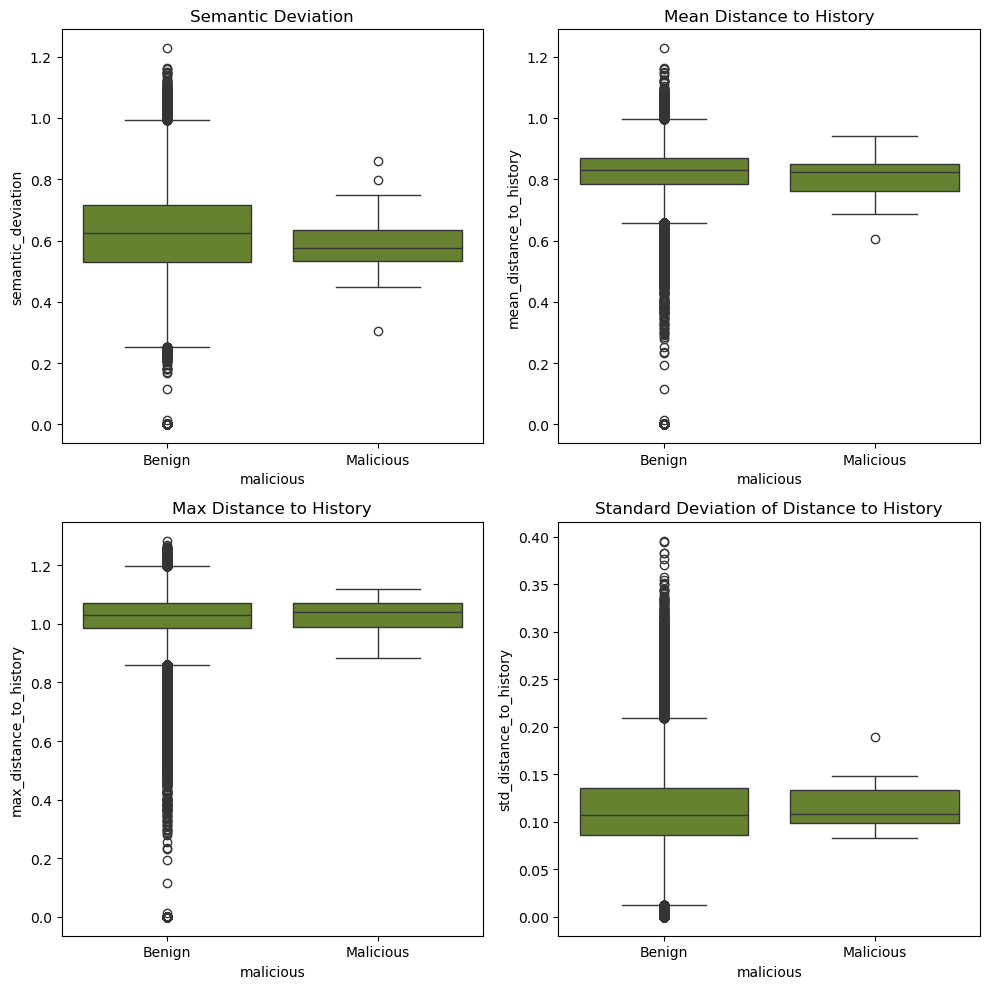

In [31]:
# Create a copy of the dataset for visualisation
plot_semantic_df = metadata_embedding_semantic.copy()

# convert class labels
plot_semantic_df["malicious"] = plot_semantic_df["malicious"].map({
    0: "Benign",
    1: "Malicious"
})

# Visualise the distribution of semantic anomaly features by class
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

sns.boxplot(
    data=plot_semantic_df,
    x="malicious",
    y="semantic_deviation",
    color="olivedrab",
    ax=ax[0,0]
)
ax[0,0].set_title("Semantic Deviation")


sns.boxplot(
    data=plot_semantic_df,
    x="malicious",
    y="mean_distance_to_history",
    color="olivedrab",
    ax=ax[0,1]
)
ax[0,1].set_title("Mean Distance to History")


sns.boxplot(
    data=plot_semantic_df,
    x="malicious",
    y="max_distance_to_history",
    color="olivedrab",
    ax=ax[1,0]
)
ax[1,0].set_title("Max Distance to History")


sns.boxplot(
    data=plot_semantic_df,
    x="malicious",
    y="std_distance_to_history",
    color="olivedrab",
    ax=ax[1,1]
)
ax[1,1].set_title("Standard Deviation of Distance to History")

plt.tight_layout()
plt.show()

In [32]:
metadata.to_pickle("metadata.pkl")
metadata_tfidf.to_pickle("metadata_tfidf.pkl")
metadata_llm_embedding.to_pickle("metadata_llm_embedding.pkl")
metadata_embedding_semantic.to_pickle("metadata_embedding_semantic.pkl")